In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#--- FUZZIFICAZIONE---
def membership_triangular(x, a, b, c):
    #x: il valore di input da valutare (Vf)
    #a: il limite sinistro dove l'appartenenza inizia a essere > 0.
    #b: il picco massimo dove l'appartenenza è esattamente 1.0
    #c: il limite destro dove l'appartenenza torna a 0
    #Calcola l'appartenenza con forma triangolare/trapezoidale.
    return np.maximum(
        0, np.minimum((x - a) / (b - a + 1e-9), (c - x) / (c - b + 1e-9))) 

def fuzzify(Vf): #Crea la funzione che prende la tensione d'ingresso Vf e la converte in valori fuzzy per le tre classi di illuminazione.
    #GRADI DI APPARTENENZA
    mu_buio = membership_triangular(Vf, -0.2, 0.0, 0.4) 
    mu_penombra = membership_triangular(Vf, 0.2, 0.5, 0.8)
    mu_luce = membership_triangular(Vf, 0.6, 1.0, 1.2)
    return mu_buio, mu_penombra, mu_luce 

#--- MODELLI FUZZY---
def tsk_zero_order(Vf):
    mu_buio, mu_penombra, mu_luce = fuzzify(Vf)
    Z1, Z2, Z3 = 100.0, 40.0, 0.0 #potenza della lampdada
    num = (mu_buio * Z1) + (mu_penombra * Z2) + (mu_luce * Z3) #numeratore
    den = mu_buio + mu_penombra + mu_luce + 1e-9 #denominatore; Somma tutti i pesi (mu). Il termine 1e-9 è una misura di sicurezza per evitare l'errore di divisione per zero
    return num / den


def tsk_first_order(Vf):
    mu_buio, mu_penombra, mu_luce = fuzzify(Vf) #Estrae i gradi di appartenenza (mu) per ciascun insieme fuzzy a partire dalla tensione d'ingresso V_f.
    Z1 = -100.0 * Vf + 100.0 #mx+q, questi sono i valori per ottenere certe uscite
    Z2 = -80.0 * Vf + 80.0
    Z3 = 0.0
    num = (mu_buio * Z1) + (mu_penombra * Z2) + (mu_luce * Z3)
    den = mu_buio + mu_penombra + mu_luce + 1e-9
    return np.clip(num / den, 0.0, 100.0) #taglia" qualsiasi valore all'interno dell'intervallo di sicurezza


def mamdani_detailed(Vf, num_points=500):
    mu_buio, mu_penombra, mu_luce = fuzzify(Vf)
    out_grid = np.linspace(0, 100, num_points)  #Crea un vettore di numeri distribuiti uniformemente tra 0 e 100

    out_buio = membership_triangular(out_grid, 60, 100, 100)
    out_penombra = membership_triangular(out_grid, 20, 50, 80)
    out_luce = membership_triangular(out_grid, 0, 0, 40)

    area_buio = np.minimum(mu_buio, out_buio)
    area_penombra = np.minimum(mu_penombra, out_penombra)
    area_luce = np.minimum(mu_luce, out_luce)

    agg_area = np.maximum(area_buio, np.maximum(area_penombra, area_luce))
    sum_area = np.sum(agg_area)
    centroid = (np.sum(out_grid * agg_area) / sum_area) if sum_area > 0 else 0.0 

    return centroid, out_grid, agg_area, (area_buio, area_penombra, area_luce), (out_buio, out_penombra, out_luce), (mu_buio, mu_penombra, mu_luce)


def mamdani(Vf):
    centroid, _, _, _, _, _ = mamdani_detailed(Vf)
    return centroid

In [ ]:
#--- GENERAZIONE DATI DI LABORATORIO---
# Simulazione Dinamica Breve
t = np.linspace(0, 50, 500) #asse di tempo 50 secondi in 500 istanti, al variare del tempo l'efficienza del TSK-1 è più visibile
Vf_time = 0.5 * (1 + np.sin(2 * np.pi * 0.1 * t)) #Genera un segnale di tensione del sensore che oscilla nel tempo come un'onda sinusoidale tra 0 e 1. V a una frequenza di 0.1 Hz

benchmark_out = [] #in base alla tensione creiamo un sistema che mi definisce lo stato del LED
state = 0.0
for v in Vf_time: #V=Vf, considero che in base al potenziale percepito ho uno stato diverso della lampada
    if v < 0.3:
        state = 100.0
    elif v > 0.7:
        state = 0.0
    benchmark_out.append(state)

out_tsk_zero = [tsk_zero_order(v) for v in Vf_time] #Calcola la potenza erogata alla lampada momento per momento per tutta la durata della simulazione (500 punti) per ciascun algoritmo:
out_tsk_first = [tsk_first_order(v) for v in Vf_time]
out_mamdani = [mamdani(v) for v in Vf_time]

dt = t[1] - t[0]  #il passo di integrazione temporale= 0.1s
energy_bin = np.cumsum(benchmark_out) * dt #integra la potenza nel tempo
energy_tsk_zero = np.cumsum(out_tsk_zero) * dt
energy_tsk_first = np.cumsum(out_tsk_first) * dt
energy_mamdani = np.cumsum(out_mamdani) * dt

# Simulazione 24 Ore
hours = np.linspace(0, 24, 1440)  # 1 campione al minuto per 24 ore


def solar_profile(h):
    if 6.0 <= h <= 20.0: #sorge alle 6 e tramonta alle 20 =14h di giorno
        return np.sin(np.pi * (h - 6.0) / 14.0) ** 1.5 #forma della luce
    else:
        return 0.0 


Vf_day = np.array([solar_profile(h) for h in hours]) #tensione durante le ore di giorno

day_schmitt = [] #stato tradizionale
state_day = 100.0
for v in Vf_day:
    if v < 0.25:
        state_day = 100.0
    elif v > 0.65:
        state_day = 0.0
    day_schmitt.append(state_day)

day_tsk0 = [tsk_zero_order(v) for v in Vf_day] #Calcola la potenza istantanea erogata dalla lampada per ogni minuto della giornata per i tre approcci Fuzzy
day_tsk1 = [tsk_first_order(v) for v in Vf_day]
day_mamdani = [mamdani(v) for v in Vf_day]

<>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:43: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:51: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:67: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:10: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:35: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

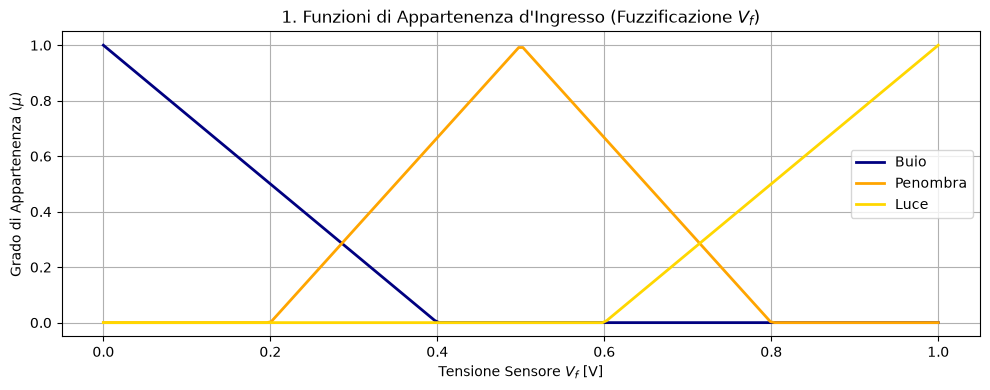

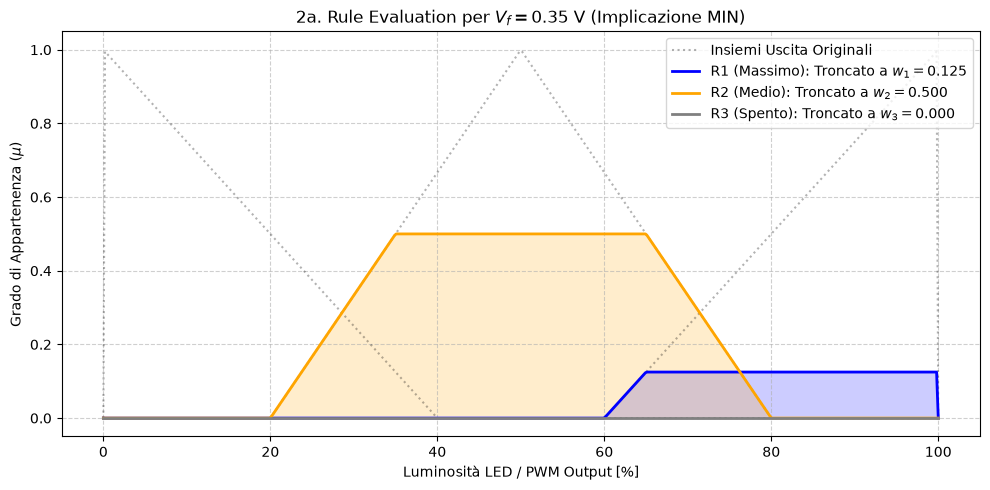

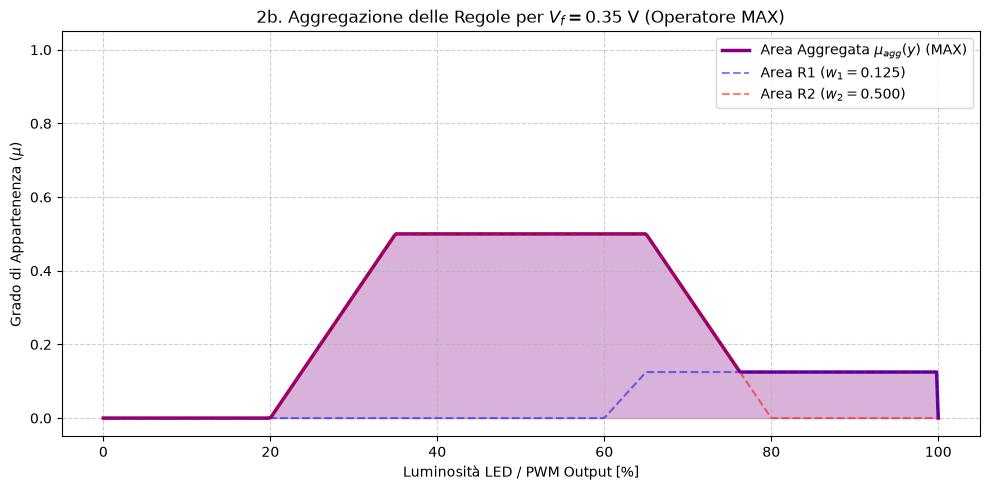

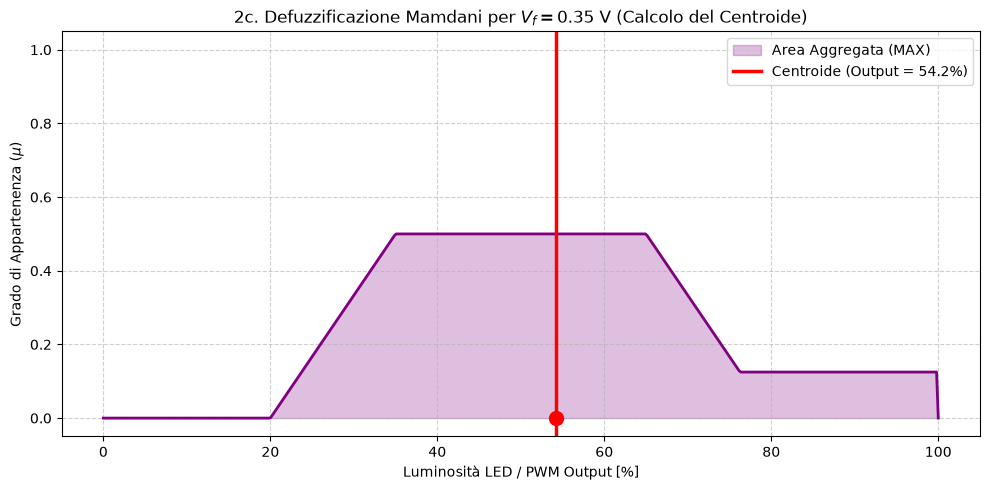

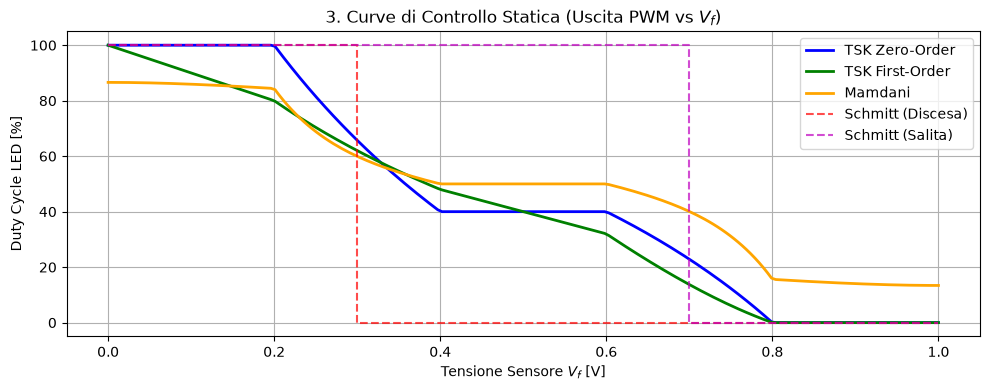

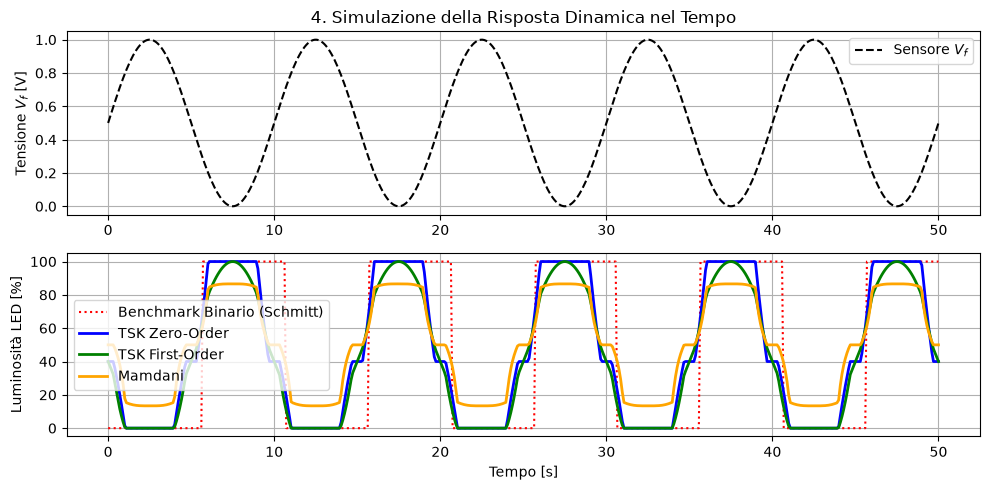

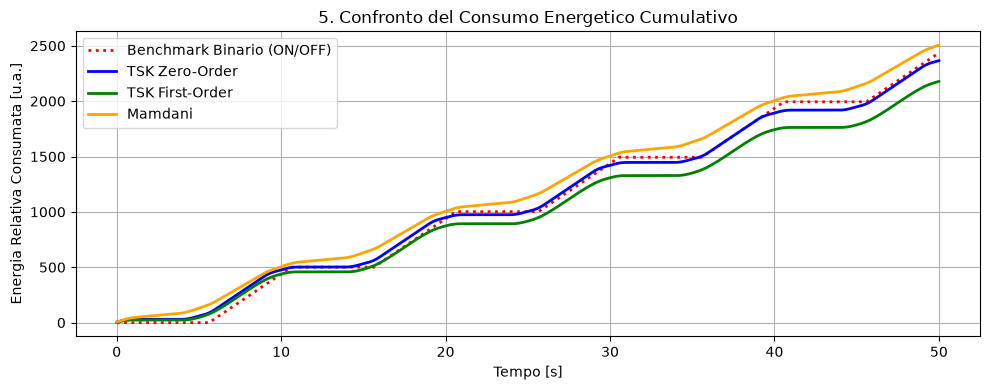

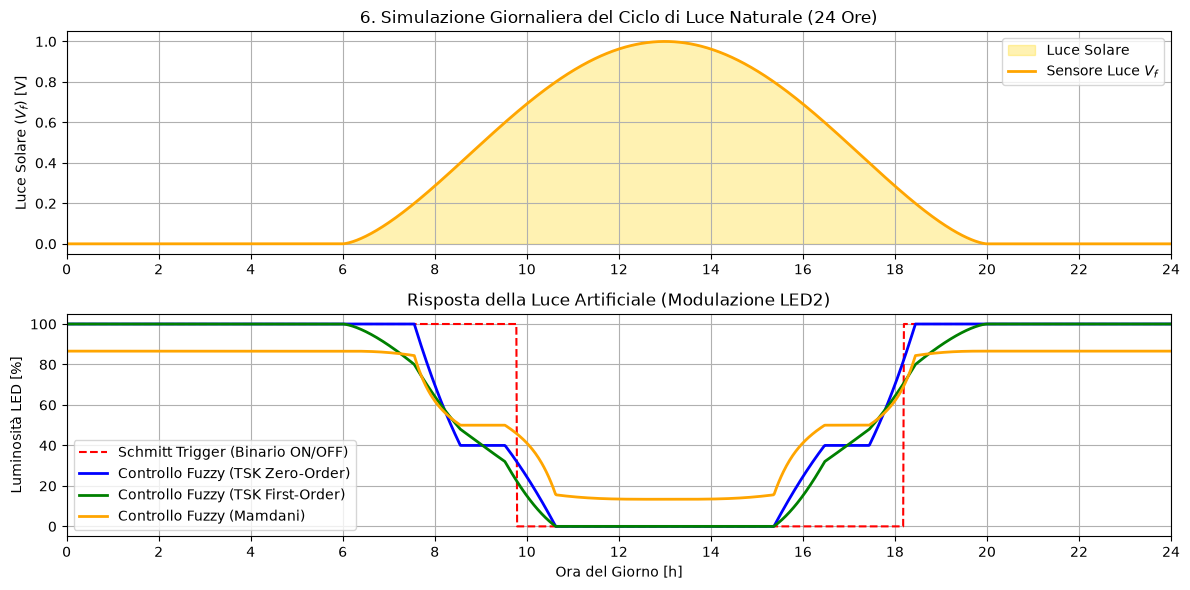

In [6]:
# --- FIGURA 1: Funzioni di Appartenenza ---
plt.figure(figsize=(10, 4))
v_range = np.linspace(0, 1, 200) #Genera un intervallo continuo di 200 valori di tensione da 0 a 1V da proiettare sull'asse x.
mu_b, mu_p, mu_l = zip(*[fuzzify(v) for v in v_range]) #Calcola i tre valori mu per ciascuno dei 200 punti di tensione e la zip li "spacchetta" sull'asse tutti e 3
plt.plot(v_range, mu_b, label="Buio", color="navy", linewidth=2)
plt.plot(v_range, mu_p, label="Penombra", color="orange", linewidth=2)
plt.plot(v_range, mu_l, label="Luce", color="gold", linewidth=2)
plt.title("1. Funzioni di Appartenenza d'Ingresso (Fuzzificazione $V_f$)")
plt.xlabel("Tensione Sensore $V_f$ [V]")
plt.ylabel("Grado di Appartenenza ($\mu$)")
plt.grid(True)
plt.legend()
plt.tight_layout()

# --- FIGURA 2A: Rule Evaluation per Vf = 0.35 V ---
test_Vf = 0.35
centroid, out_grid, agg_area, (a_b, a_p, a_l), (o_b, o_p, o_l), (w1, w2, w3) = mamdani_detailed(test_Vf) #Calcola la risposta Mamdani per la tensione di prova 0.35V

plt.figure(figsize=(10, 5))
plt.plot(out_grid, o_b, 'k:', alpha=0.3, label='Insiemi Uscita Originali') #disegna le linee tratteggiate prima del taglio con linee tratteggiate e semitrasparenti
plt.plot(out_grid, o_p, 'k:', alpha=0.3)
plt.plot(out_grid, o_l, 'k:', alpha=0.3)

plt.plot(out_grid, a_b, color='blue', linewidth=2, label=f'R1 (Massimo): Troncato a $w_1 = {w1:.3f}$')
plt.fill_between(out_grid, 0, a_b, color='blue', alpha=0.2)

plt.plot(out_grid, a_p, color='orange', linewidth=2, label=f'R2 (Medio): Troncato a $w_2 = {w2:.3f}$')
plt.fill_between(out_grid, 0, a_p, color='orange', alpha=0.2)

plt.plot(out_grid, a_l, color='gray', linewidth=2, label=f'R3 (Spento): Troncato a $w_3 = {w3:.3f}$')
plt.fill_between(out_grid, 0, a_l, color='gray', alpha=0.2)

plt.title(f'2a. Rule Evaluation per $V_f = {test_Vf}$ V (Implicazione MIN)')
plt.xlabel('Luminosità LED / PWM Output [%]')
plt.ylabel('Grado di Appartenenza ($\mu$)')
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# --- FIGURA 2B: Aggregazione delle Regole ---
plt.figure(figsize=(10, 5))
plt.plot(out_grid, agg_area, color='purple', linewidth=2.5, label='Area Aggregata $\mu_{agg}(y)$ (MAX)')
plt.fill_between(out_grid, 0, agg_area, color='purple', alpha=0.3) #Colora in viola semitrasparente l'unica grande figura geometrica risultante dalla fusione (unione) di tutte le regole attive.

plt.plot(out_grid, a_b, 'b--', alpha=0.5, label=f'Area R1 ($w_1={w1:.3f}$)')
plt.plot(out_grid, a_p, 'r--', alpha=0.5, label=f'Area R2 ($w_2={w2:.3f}$)')

plt.title(f'2b. Aggregazione delle Regole per $V_f = {test_Vf}$ V (Operatore MAX)')
plt.xlabel('Luminosità LED / PWM Output [%]')
plt.ylabel('Grado di Appartenenza ($\mu$)')
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# --- FIGURA 2C: Defuzzificazione (Centroide) ---
plt.figure(figsize=(10, 5))
plt.plot(out_grid, agg_area, color='purple', linewidth=2)
plt.fill_between(out_grid, 0, agg_area, color='purple', alpha=0.25, label='Area Aggregata (MAX)')

plt.axvline(centroid, color='red', linestyle='-', linewidth=2.5, label=f'Centroide (Output = {centroid:.1f}%)')
plt.scatter([centroid], [0], color='red', s=100, zorder=5)

plt.title(f'2c. Defuzzificazione Mamdani per $V_f = {test_Vf}$ V (Calcolo del Centroide)')
plt.xlabel('Luminosità LED / PWM Output [%]')
plt.ylabel('Grado di Appartenenza ($\mu$)')
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()

# --- FIGURA 3: Curve Statiche ---
plt.figure(figsize=(10, 4))
v_static = np.linspace(0, 1, 200)
y_tsk0 = [tsk_zero_order(v) for v in v_static]
y_tsk1 = [tsk_first_order(v) for v in v_static]
y_mam = [mamdani(v) for v in v_static]
plt.plot(v_static, y_tsk0, label="TSK Zero-Order", color="blue", linewidth=2)
plt.plot(v_static, y_tsk1, label="TSK First-Order", color="green", linewidth=2)
plt.plot(v_static, y_mam, label="Mamdani", color="orange", linewidth=2)
plt.plot(
    [0, 0.3, 0.3, 1], [100, 100, 0, 0], "r--", label="Schmitt (Discesa)", alpha=0.7
)
plt.plot(
    [0, 0.7, 0.7, 1], [100, 100, 0, 0], "m--", label="Schmitt (Salita)", alpha=0.7
)
plt.title("3. Curve di Controllo Statica (Uscita PWM vs $V_f$)")
plt.xlabel("Tensione Sensore $V_f$ [V]")
plt.ylabel("Duty Cycle LED [%]")
plt.grid(True)
plt.legend()
plt.tight_layout()

# --- FIGURA 4: Risposta Dinamica ---
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(t, Vf_time, label="Sensore $V_f$", color="black", linestyle="--")
plt.title("4. Simulazione della Risposta Dinamica nel Tempo")
plt.ylabel("Tensione $V_f$ [V]")
plt.grid(True)
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(
    t,
    benchmark_out,
    label="Benchmark Binario (Schmitt)",
    color="red",
    linestyle=":",
    linewidth=1.5,
)
plt.plot(t, out_tsk_zero, label="TSK Zero-Order", color="blue", linewidth=2)
plt.plot(t, out_tsk_first, label="TSK First-Order", color="green", linewidth=2)
plt.plot(t, out_mamdani, label="Mamdani", color="orange", linewidth=2)
plt.xlabel("Tempo [s]")
plt.ylabel("Luminosità LED [%]")
plt.grid(True)
plt.legend()
plt.tight_layout()

# --- FIGURA 5: Consumo Energetico Cumulativo ---
plt.figure(figsize=(10, 4))
plt.plot(
    t,
    energy_bin,
    label="Benchmark Binario (ON/OFF)",
    color="red",
    linewidth=2,
    linestyle=":",
)
plt.plot(t, energy_tsk_zero, label="TSK Zero-Order", color="blue", linewidth=2)
plt.plot(
    t, energy_tsk_first, label="TSK First-Order", color="green", linewidth=2
)
plt.plot(t, energy_mamdani, label="Mamdani", color="orange", linewidth=2)
plt.title("5. Confronto del Consumo Energetico Cumulativo")
plt.xlabel("Tempo [s]")
plt.ylabel("Energia Relativa Consumata [u.a.]")
plt.grid(True)
plt.legend()
plt.tight_layout()

# --- FIGURA 6: EVOLUZIONE NELL'ARCO DELLA GIORNATA (24 ORE) ---
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.fill_between(hours, 0, Vf_day, color="gold", alpha=0.3, label="Luce Solare")
plt.plot(
    hours, Vf_day, color="orange", linewidth=2, label="Sensore Luce $V_f$"
)
plt.title("6. Simulazione Giornaliera del Ciclo di Luce Naturale (24 Ore)")
plt.ylabel("Luce Solare ($V_f$) [V]")
plt.xticks(np.arange(0, 25, 2))
plt.xlim(0, 24)
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(
    hours,
    day_schmitt,
    label="Schmitt Trigger (Binario ON/OFF)",
    color="red",
    linestyle="--",
    linewidth=1.5,
)
plt.plot(
    hours,
    day_tsk0,
    label="Controllo Fuzzy (TSK Zero-Order)",
    color="blue",
    linewidth=2,
)
plt.plot(
    hours,
    day_tsk1,
    label="Controllo Fuzzy (TSK First-Order)",
    color="green",
    linewidth=2,
)  
plt.plot(
    hours,
    day_mamdani,
    label="Controllo Fuzzy (Mamdani)",
    color="orange",
    linewidth=2,
)

plt.title("Risposta della Luce Artificiale (Modulazione LED2)")
plt.xlabel("Ora del Giorno [h]")
plt.ylabel("Luminosità LED [%]")
plt.xticks(np.arange(0, 25, 2))
plt.xlim(0, 24)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

<>:105: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:105: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\Angela\AppData\Local\Temp\ipykernel_10136\3389260246.py:105: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel("Peso d'Attivazione della Regola $w_i$ ($\mu$)")


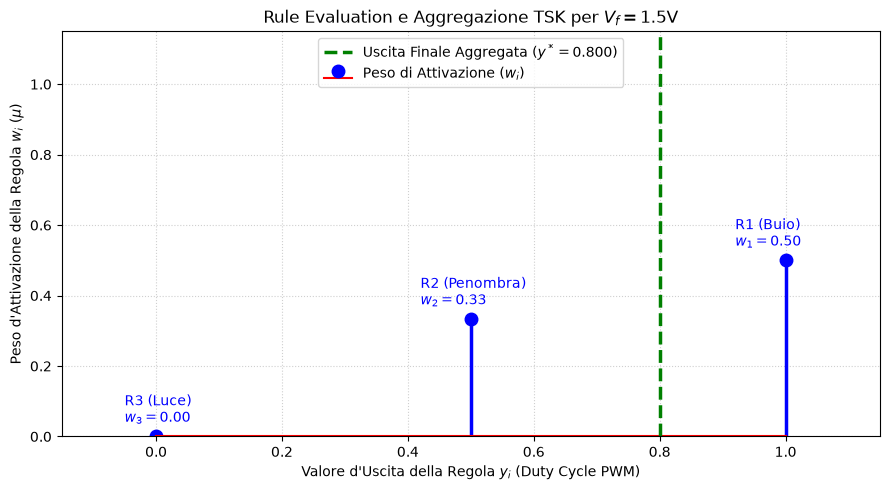

In [ ]:
def mu_buio(vf):
    return (
        1.0
        if vf <= 1.0 #se la tensione è <1V è completamente buio
        else (2.0 - vf) / (2.0 - 1.0) #se è compresa tra 1 e 2 segue una discesa lineare e il grado di buio scende a 0
        if 1.0 < vf < 2.0
        else 0.0 #se V>2 non è più buio
    )

#stesso processo per le tre curve
def mu_penombra(vf):
    return (
        (vf - 1.0) / (2.5 - 1.0)
        if 1.0 < vf <= 2.5
        else (4.0 - vf) / (4.0 - 2.5)
        if 2.5 < vf < 4.0
        else 0.0
    )


def mu_luce(vf):
    return (
        0.0
        if vf <= 3.0
        else (vf - 3.0) / (4.0 - 3.0)
        if 3.0 < vf < 4.0
        else 1.0
    )


def tsk_system(vf_val):
    # Fuzzificazione & Rule Evaluation (Pesi wi)
    w1 = mu_buio(vf_val)
    w2 = mu_penombra(vf_val)
    w3 = mu_luce(vf_val)

    # Conseguenze fisse (Ordine Zero)
    y1, y2, y3 = 1.0, 0.5, 0.0  # Duty Cycle: 100%, 50%, 0%

    pesi = np.array([w1, w2, w3])
    uscite = np.array([y1, y2, y3])

    # Aggregazione e Media Pesata
    y_star = np.sum(pesi * uscite) / np.sum(pesi)

    return pesi, uscite, y_star


#  ---GENERAZIONE DEL GRAFICO---#

vf_test = 1.5  # Tensione di test (es. Tramonto)
pesi, uscite, y_star = tsk_system(vf_test)

fig, ax = plt.subplots(figsize=(9, 5))

# Disegna le aste verticali (Aste blu = Pesi delle regole)
markerline, stemlines, baseline = ax.stem(
    uscite,
    pesi,
    linefmt="b-",
    markerfmt="bo",
    basefmt="r-",
    label="Peso di Attivazione ($w_i$)",
)
plt.setp(stemlines, linewidth=2.5)
plt.setp(markerline, markersize=9)

# Disegna la linea dell'uscita finale (Media Pesata)
ax.axvline(
    x=y_star,
    color="green",
    linestyle="--",
    linewidth=2.5,
    label=f"Uscita Finale Aggregata ($y^* = {y_star:.3f}$)",
)

# Etichette sulle aste (corretta l'indicazione di R2)
ax.text(
    uscite[0] - 0.08,
    pesi[0] + 0.04,
    f"R1 (Buio)\n$w_1 = {pesi[0]:.2f}$",
    fontsize=10,
    color="blue",
)
ax.text(
    uscite[1] - 0.08,
    pesi[1] + 0.04,
    f"R2 (Penombra)\n$w_2 = {pesi[1]:.2f}$",
    fontsize=10,
    color="blue",
)
ax.text(
    uscite[2] - 0.05,
    pesi[2] + 0.04,
    f"R3 (Luce)\n$w_3 = {pesi[2]:.2f}$",
    fontsize=10,
    color="blue",
)

ax.set_title(
    f"Rule Evaluation e Aggregazione TSK per $V_f = {vf_test}\\text{{V}}$",
    fontsize=12,
)
ax.set_xlabel("Valore d'Uscita della Regola $y_i$ (Duty Cycle PWM)")
ax.set_ylabel("Peso d'Attivazione della Regola $w_i$ ($\mu$)")
ax.set_xlim(-0.15, 1.15)
ax.set_ylim(0, 1.15)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper center")

plt.tight_layout()
plt.show()

Iterazioni | Mamdani (s)  | TSK Ord.0 (s) | TSK Ord.1 (s) | Speedup (vs Mamdani)
---------------------------------------------------------------------------
1000       | 0.04818      | 0.00028       | 0.00617       | TSK0: 171x | TSK1: 8x
5000       | 0.19090      | 0.00115       | 0.02413       | TSK0: 166x | TSK1: 8x
10000      | 0.38631      | 0.00224       | 0.05171       | TSK0: 173x | TSK1: 7x
50000      | 1.87349      | 0.01319       | 0.22375       | TSK0: 142x | TSK1: 8x
100000     | 3.87269      | 0.03380       | 0.47858       | TSK0: 115x | TSK1: 8x


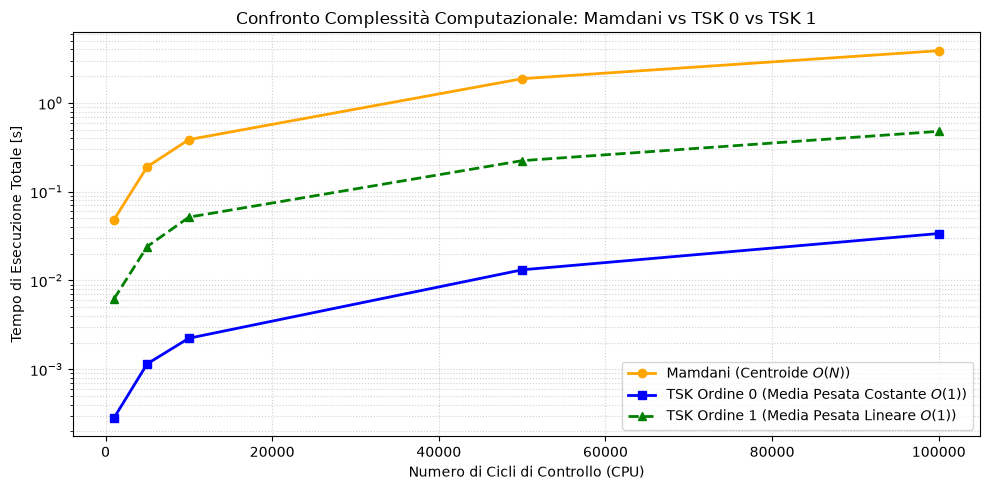

In [ ]:
import time

def mamdani_defuzzification(weights, num_points=1000):
    """Defuzzificazione Mamdani (Centroide su griglia discretizzata). """
    w1, w2, w3 = weights 
    out_grid = np.linspace(0, 100, num_points) #punti distribuiti equamente sull'uscita tra 0 e 100

    shape_buio = np.maximum(0, (out_grid - 60) / 40) #forma delle "rampe"
    shape_penombra = np.maximum(
        0, np.minimum((out_grid - 20) / 30, (80 - out_grid) / 30)
    )
    shape_luce = np.maximum(0, (40 - out_grid) / 40)

    area_buio = np.minimum(w1, shape_buio)
    area_penombra = np.minimum(w2, shape_penombra)
    area_luce = np.minimum(w3, shape_luce)

    agg_area = np.maximum(area_buio, np.maximum(area_penombra, area_luce))

    sum_area = np.sum(agg_area)
    if sum_area > 0:
        centroid = np.sum(out_grid * agg_area) / sum_area
    else:
        centroid = 0.0

    return centroid


def tsk_zero_order(weights):
    w1, w2, w3 = weights
    # Conseguenze fisse (singoli valori scalari)
    y1, y2, y3 = 100.0, 50.0, 0.0

    num = (w1 * y1) + (w2 * y2) + (w3 * y3)
    den = w1 + w2 + w3 + 1e-9

    return num / den


def tsk_first_order(weights, vf):

    w1, w2, w3 = weights
    # Conseguenze equazioni di retta
    y1 = -100.0 * vf + 100.0
    y2 = -80.0 * vf + 80.0
    y3 = 0.0

    num = (w1 * y1) + (w2 * y2) + (w3 * y3)
    den = w1 + w2 + w3 + 1e-9

    return np.clip(num / den, 0.0, 100.0)

num_iterations = [1000, 5000, 10000, 50000, 100000]
weights_sample = [0.50, 0.33, 0.00]  # Pesi di test
vf_sample = 0.3  # Tensione di test per TSK-1

times_mamdani = [] #salvare i tempi d'esecuzione espressi in second
times_tsk0 = []
times_tsk1 = []

for n in num_iterations: #Inizia un ciclo principale che prende uno alla volta i valori di iterazione definiti nella lista
    # --- TEST MAMDANI ---
    start = time.perf_counter() #cronometro
    for _ in range(n):
        _ = mamdani_defuzzification(weights_sample, num_points=200)
    times_mamdani.append(time.perf_counter() - start) #ferma il counter e sottrae la partenza

    # --- TEST TSK ORDINE 0 ---
    start = time.perf_counter()
    for _ in range(n):
        _ = tsk_zero_order(weights_sample)
    times_tsk0.append(time.perf_counter() - start)

    # --- TEST TSK ORDINE 1 ---
    start = time.perf_counter()
    for _ in range(n):
        _ = tsk_first_order(weights_sample, vf_sample)
    times_tsk1.append(time.perf_counter() - start)

print(
    f"{'Iterazioni':<10} | {'Mamdani (s)':<12} | {'TSK Ord.0 (s)':<13} | {'TSK Ord.1 (s)':<13} | Speedup (vs Mamdani)" #questa scrittura è per avere una buona incolonnazione
)
print("-" * 75)
for i in range(len(num_iterations)):
    speedup0 = times_mamdani[i] / times_tsk0[i]
    speedup1 = times_mamdani[i] / times_tsk1[i]
    print(
        f"{num_iterations[i]:<10} | {times_mamdani[i]:<12.5f} | {times_tsk0[i]:<13.5f} | {times_tsk1[i]:<13.5f} | TSK0: {speedup0:.0f}x | TSK1: {speedup1:.0f}x"
    )

# Grafico Comparativo
plt.figure(figsize=(10, 5))
plt.plot(
    num_iterations,
    times_mamdani,
    "o-",
    color="orange",
    linewidth=2,
    label="Mamdani (Centroide $O(N)$)",
)
plt.plot(
    num_iterations,
    times_tsk0,
    "s-",
    color="blue",
    linewidth=2,
    label="TSK Ordine 0 (Media Pesata Costante $O(1)$)",
)
plt.plot(
    num_iterations,
    times_tsk1,
    "^--",
    color="green",
    linewidth=2,
    label="TSK Ordine 1 (Media Pesata Lineare $O(1)$)",
)

plt.title(
    "Confronto Complessità Computazionale: Mamdani vs TSK 0 vs TSK 1",
    fontsize=12,
)
plt.xlabel("Numero di Cicli di Controllo (CPU)")
plt.ylabel("Tempo di Esecuzione Totale [s]")
plt.yscale("log")  # Scala logaritmica per apprezzare le differenze
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()